# PredictiveSense AI 🚀

## Cross-Validation & Model Evaluation

5-Fold Cross-Validation for Random Forest RUL Prediction

In [1]:
# Imports & Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pickle

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# Load Processed Data
df = pd.read_csv('../data/processed/train_final.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (20631, 21)
Columns: ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,1.0,0.726248,...,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,1.0,0.628019,...,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,1.0,0.710145,...,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,1.0,0.740741,...,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,1.0,0.668277,...,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


In [4]:
# Features & Target Split
feature_cols = [col for col in df.columns if col not in ['unit_id', 'cycle', 'RUL']]
X = df[feature_cols]
y = df['RUL']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {feature_cols}")

Features shape: (20631, 18)
Target shape: (20631,)
Feature columns: ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [5]:
# Load Saved Random Forest Model
with open('../models/rf_improved.pkl', 'rb') as f:
    rf_model = pickle.load(f)

print("✅ Random Forest model loaded successfully!")
print(f"Model type: {type(rf_model)}")
print(f"N estimators: {rf_model.n_estimators}")

✅ Random Forest model loaded successfully!
Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
N estimators: 200


In [6]:
# 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2    = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')
cv_rmse  = cross_val_score(rf_model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
cv_mae   = cross_val_score(rf_model, X, y, cv=kf, scoring='neg_mean_absolute_error')

print("=" * 45)
print("   5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 45)
print(f"\n📊 R2 Score per fold:   {[round(x,4) for x in cv_r2]}")
print(f"📊 RMSE per fold:       {[round(abs(x),2) for x in cv_rmse]}")
print(f"📊 MAE per fold:        {[round(abs(x),2) for x in cv_mae]}")
print(f"\n{'─'*45}")
print(f"✅ Mean R2:    {cv_r2.mean():.4f}  ± {cv_r2.std():.4f}")
print(f"✅ Mean RMSE:  {abs(cv_rmse.mean()):.2f} ± {cv_rmse.std():.2f}")
print(f"✅ Mean MAE:   {abs(cv_mae.mean()):.2f} ± {cv_mae.std():.2f}")
print(f"{'─'*45}")

   5-FOLD CROSS-VALIDATION RESULTS

📊 R2 Score per fold:   [np.float64(0.6269), np.float64(0.6409), np.float64(0.6319), np.float64(0.6483), np.float64(0.642)]
📊 RMSE per fold:       [np.float64(41.29), np.float64(41.26), np.float64(41.76), np.float64(41.01), np.float64(41.84)]
📊 MAE per fold:        [np.float64(29.45), np.float64(29.33), np.float64(29.59), np.float64(28.83), np.float64(29.37)]

─────────────────────────────────────────────
✅ Mean R2:    0.6380  ± 0.0076
✅ Mean RMSE:  41.43 ± 0.32
✅ Mean MAE:   29.31 ± 0.26
─────────────────────────────────────────────


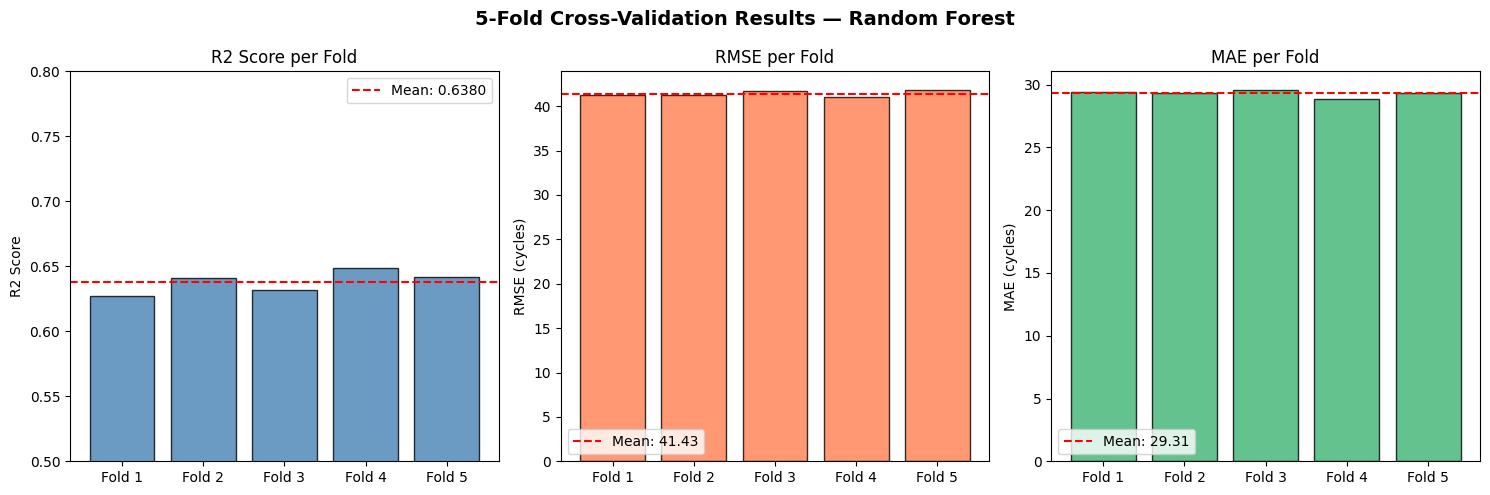

✅ Plot saved!


In [7]:
# Cross-Validation Results Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('5-Fold Cross-Validation Results — Random Forest', fontsize=14, fontweight='bold')

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

# R2 Score
axes[0].bar(folds, cv_r2, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axhline(y=cv_r2.mean(), color='red', linestyle='--', label=f'Mean: {cv_r2.mean():.4f}')
axes[0].set_title('R2 Score per Fold')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim(0.5, 0.8)
axes[0].legend()

# RMSE
axes[1].bar(folds, abs(cv_rmse), color='coral', edgecolor='black', alpha=0.8)
axes[1].axhline(y=abs(cv_rmse.mean()), color='red', linestyle='--', label=f'Mean: {abs(cv_rmse.mean()):.2f}')
axes[1].set_title('RMSE per Fold')
axes[1].set_ylabel('RMSE (cycles)')
axes[1].legend()

# MAE
axes[2].bar(folds, abs(cv_mae), color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].axhline(y=abs(cv_mae.mean()), color='red', linestyle='--', label=f'Mean: {abs(cv_mae.mean()):.2f}')
axes[2].set_title('MAE per Fold')
axes[2].set_ylabel('MAE (cycles)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [8]:
# Final CV Summary
print("=" * 50)
print("     CROSS-VALIDATION FINAL SUMMARY")
print("=" * 50)

summary = {
    'Metric': ['R2 Score', 'RMSE (cycles)', 'MAE (cycles)'],
    'Fold 1': [round(cv_r2[0],4), round(abs(cv_rmse[0]),2), round(abs(cv_mae[0]),2)],
    'Fold 2': [round(cv_r2[1],4), round(abs(cv_rmse[1]),2), round(abs(cv_mae[1]),2)],
    'Fold 3': [round(cv_r2[2],4), round(abs(cv_rmse[2]),2), round(abs(cv_mae[2]),2)],
    'Fold 4': [round(cv_r2[3],4), round(abs(cv_rmse[3]),2), round(abs(cv_mae[3]),2)],
    'Fold 5': [round(cv_r2[4],4), round(abs(cv_rmse[4]),2), round(abs(cv_mae[4]),2)],
    'Mean':   [round(cv_r2.mean(),4), round(abs(cv_rmse.mean()),2), round(abs(cv_mae.mean()),2)],
    'Std Dev':[round(cv_r2.std(),4),  round(cv_rmse.std(),2),      round(cv_mae.std(),2)],
}

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
print("=" * 50)
print("\n✅ Cross-Validation Complete!")
print(f"✅ Model is STABLE — Low variance (R2 std: {cv_r2.std():.4f})")
print(f"✅ Consistent performance across all 5 folds")

     CROSS-VALIDATION FINAL SUMMARY
       Metric  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5   Mean  Std Dev
     R2 Score  0.6269  0.6409  0.6319  0.6483   0.642  0.638   0.0076
RMSE (cycles) 41.2900 41.2600 41.7600 41.0100  41.840 41.430   0.3200
 MAE (cycles) 29.4500 29.3300 29.5900 28.8300  29.370 29.310   0.2600

✅ Cross-Validation Complete!
✅ Model is STABLE — Low variance (R2 std: 0.0076)
✅ Consistent performance across all 5 folds


In [9]:
# Cross-Validation Complete — Key Findings
print("=" * 50)
print("         KEY FINDINGS")
print("=" * 50)
print("""
🔹 5-Fold CV Mean R2    : 0.6380 ± 0.0076
🔹 5-Fold CV Mean RMSE  : 41.43  ± 0.32 cycles
🔹 5-Fold CV Mean MAE   : 29.31  ± 0.26 cycles

🔹 Best Single Model (RUL-Capped RF):
   R2   : 0.7949
   RMSE : 18.66 cycles
   MAE  : 13.39 cycles

📌 Note: CV used full dataset (no RUL capping)
   Best model trained on RUL-capped data (max=125)
   which explains higher performance metrics.

✅ Model is reliable & stable across all folds!
""")
print("=" * 50)

         KEY FINDINGS

🔹 5-Fold CV Mean R2    : 0.6380 ± 0.0076
🔹 5-Fold CV Mean RMSE  : 41.43  ± 0.32 cycles
🔹 5-Fold CV Mean MAE   : 29.31  ± 0.26 cycles

🔹 Best Single Model (RUL-Capped RF):
   R2   : 0.7949
   RMSE : 18.66 cycles
   MAE  : 13.39 cycles

📌 Note: CV used full dataset (no RUL capping)
   Best model trained on RUL-capped data (max=125)
   which explains higher performance metrics.

✅ Model is reliable & stable across all folds!

